# Neighbour features

Crear neighbour_features, dado las características de las variables meteorológicas y las variables iniciales

## Imports

In [1]:
import datetime
import networkx as nx
import pandas as pd
import warnings


from src.data.utils import (
    get_general_path, join_paths, save_dataframe
)

## Configuration

In [2]:
warnings.filterwarnings('ignore')

## Constants

In [3]:
INTERIM_DATA = 'data/interim/'

METEOROLOGICAL_AND_INITIAL_FEATURES = 'meteorological_and_initial_features.parquet'

NEIGHBOUR_GRAPH = 'municipal_neighbour_graph.pkl'

MUNICIPAL_DATA = 'municipal_data.pkl'

ALL_FEATURES_FILE = 'all_features.pkl'

## Helper functions

In [4]:
def extract_mun_id_from_index(df):
    df['mun_id'] = list(pd.Series(features.index).apply(lambda x: x.split('__')[0]))
    return df
    
def process_neighbour_features(neighbour_grade, mun_id, features_df, graph):
    relevant_index = features_df[features_df.mun_id == mun_id].index
    neighbours = nx.descendants_at_distance(graph, mun_id, neighbour_grade)
    neighbour_features = features_df[
        features_df.mun_id.isin(neighbours)
    ].drop('mun_id', axis=1).groupby('standard_date').mean()
    renamed_cols = {col: f'{col}__neighbour{neighbour_grade}_mean' for col in neighbour_features.columns}
    neighbour_features.rename(columns=renamed_cols, inplace=True)
    return neighbour_features.set_index(relevant_index)

## Read data


In [5]:
general_path = get_general_path()

features_path = join_paths(general_path, INTERIM_DATA, METEOROLOGICAL_AND_INITIAL_FEATURES)
features = pd.read_parquet(features_path)

graph_path = join_paths(general_path, INTERIM_DATA, NEIGHBOUR_GRAPH)
neighbour_graph = pd.read_pickle(graph_path)

## Process data

In [93]:
specific_feature_date = features[features.standard_date=='2024-01-15'][['mun_id', 'num_drought_index', 'standard_date']]
specific_feature_date

,mun_id,num_drought_index,standard_date
01_001__20240115,01_001,3.0,2024-01-15
01_002__20240115,01_002,2.0,2024-01-15
01_003__20240115,01_003,3.0,2024-01-15
01_004__20240115,01_004,3.0,2024-01-15
01_005__20240115,01_005,3.0,2024-01-15
...,...,...,...
32_054__20240115,32_054,1.0,2024-01-15
32_055__20240115,32_055,3.0,2024-01-15
32_056__20240115,32_056,3.0,2024-01-15
32_057__20240115,32_057,3.0,2024-01-15


In [94]:
drought_mun0 = specific_feature_date[specific_feature_date.num_drought_index == 0].mun_id.to_list()
drought_mun = specific_feature_date[specific_feature_date.num_drought_index > 0].mun_id.to_list()


neighbour_subgraph_drought0 = neighbour_graph.subgraph(drought_mun0)
neighbour_subgraph_drought = neighbour_graph.subgraph(drought_mun)


In [95]:
closeness_centrality_drought = nx.closeness_centrality(neighbour_subgraph_drought0)
closeness_centrality_drought.update(nx.closeness_centrality(neighbour_subgraph_drought))

In [96]:
betweenness_centrality_drought = nx.betweenness_centrality(neighbour_subgraph_drought0)
betweenness_centrality_drought.update(nx.betweenness_centrality(neighbour_subgraph_drought))

In [97]:
katz_centrality_drought = nx.katz_centrality(neighbour_subgraph_drought0)
katz_centrality_drought.update(nx.katz_centrality(neighbour_subgraph_drought))

<Axes: ylabel='Frequency'>

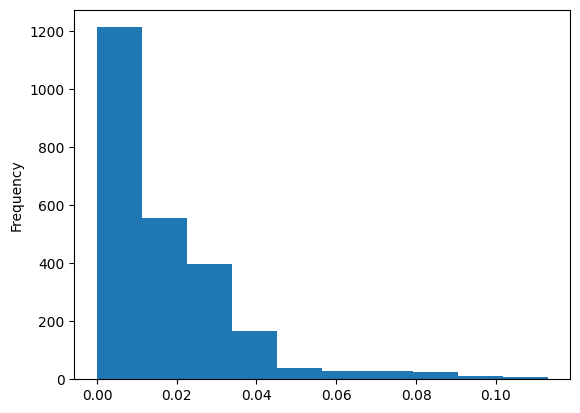

In [114]:
test = pd.DataFrame([closeness_centrality_drought_series, closeness_centrality_drought_series2, ]).T
(test[0] - test[1]).abs().plot(kind='hist')

<Axes: ylabel='Frequency'>

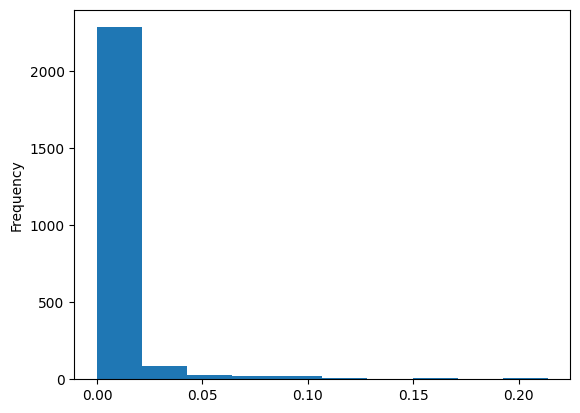

In [115]:
test = pd.DataFrame([betweenness_centrality_drought_series, betweenness_centrality_drought_series2, ]).T
(test[0] - test[1]).abs().plot(kind='hist')

01_008    0.046989
01_003    0.048838
01_005    0.048411
01_006    0.046606
01_007    0.045739
            ...   
24_018    0.031746
20_014    0.074613
20_075    0.058149
20_248    0.075065
07_041    0.006349
Length: 2471, dtype: float64

In [99]:
closeness_centrality_drought_series2 = pd.Series(closeness_centrality_drought)#.describe()


In [104]:
betweenness_centrality_drought_series2 = pd.Series(betweenness_centrality_drought)#.describe()

In [106]:
katz_centrality_drought

{'21_182': 0.03319565505548442,
 '30_206': 0.024196824167846638,
 '12_070': 0.038473602172209076,
 '14_029': 0.019459958734026013,
 '07_050': 0.017965848762844537,
 '23_005': 0.018890569550678197,
 '30_016': 0.030302162891003886,
 '30_088': 0.026753245965906256,
 '12_074': 0.032547130656677796,
 '29_037': 0.02562365032605589,
 '21_095': 0.02806549399625848,
 '07_037': 0.028222562043443155,
 '12_042': 0.03311570135342273,
 '12_017': 0.02184606795112807,
 '30_171': 0.02814875544018757,
 '28_025': 0.01999372901780487,
 '14_065': 0.024046188930187548,
 '30_028': 0.021957727462397193,
 '05_012': 0.01720323034488246,
 '19_028': 0.029428077429750114,
 '07_069': 0.02261827996065552,
 '07_092': 0.031200528738388036,
 '20_107': 0.05555282073857219,
 '20_550': 0.041765843679920873,
 '30_177': 0.030955513969638665,
 '20_233': 0.036548879463334065,
 '21_036': 0.031134739947897214,
 '20_517': 0.03448616253805178,
 '23_011': 0.01962206950903315,
 '20_473': 0.05051984261417165,
 '21_028': 0.0298264643

In [ ]:
neighbour1_feature_list = []
neighbour2_feature_list = []

for i, mun_id in enumerate(features.mun_id.unique()):
    n1 = process_neighbour_features(neighbour_grade=1, mun_id=mun_id, features_df=features, graph=neighbour_graph)
    n2 = process_neighbour_features(neighbour_grade=2, mun_id=mun_id, features_df=features, graph=neighbour_graph)
    neighbour1_feature_list.append(n1)
    neighbour2_feature_list.append(n2)
    if not i%100:
        print(mun_id, i)

In [21]:
neighbour1_features = pd.concat(neighbour1_feature_list, axis=0)
neighbour2_features = pd.concat(neighbour2_feature_list, axis=0)

In [25]:
all_features = pd.concat([features, neighbour1_features, neighbour2_features], axis=1)

## Results

In [26]:
all_features

,mun_id,num_drought_index,standard_date,num_drought_index__clv_oc__mean,num_drought_index__clv_oc__std,num_drought_index__clv_oc__max,num_drought_index__clv_oc__min,num_drought_index__clv_oc__median,num_drought_index__cve_conc__mean,num_drought_index__cve_conc__std,...,T2M_T10M_change__last90_days_range__neighbour2_mean,TO3__last90_days_range__neighbour2_mean,TQV__last90_days_range__neighbour2_mean,TROPPB__last90_days_range__neighbour2_mean,TROPQ__last90_days_range__neighbour2_mean,TROPT__last90_days_range__neighbour2_mean,TS__last90_days_range__neighbour2_mean,TS_T2M_change__last90_days_range__neighbour2_mean,TS_TROPT_range__last90_days_range__neighbour2_mean,change_difference__last90_days_range__neighbour2_mean
01_001__20160115,01_001,0.0,2016-01-15,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,...,0.196750,49.110000,28.368500,6.113000,0.020000,16.935500,11.904500,1.550750,21.519000,1.409938
01_002__20160115,01_002,0.0,2016-01-15,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,...,0.208229,50.663333,27.811667,6.064167,0.020000,16.675000,11.808333,1.638750,21.493333,1.478021
01_003__20160115,01_003,0.0,2016-01-15,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,...,0.196324,51.253529,28.252353,6.091765,0.020000,16.358235,12.467647,1.677941,22.230588,1.538897
01_004__20160115,01_004,0.0,2016-01-15,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,...,0.219821,52.741429,27.641429,5.957143,0.020000,15.911429,12.087143,1.676429,21.974286,1.515000
01_005__20160115,01_005,0.0,2016-01-15,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,...,0.198229,50.762500,28.164167,6.121667,0.020000,16.659167,12.258333,1.676250,21.965833,1.532500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32_054__20240615,32_054,1.0,2024-06-15,2.380952,1.096597,4.0,0.0,2.0,2.191489,1.244786,...,0.163750,42.551333,22.416667,6.227333,0.012667,13.445333,15.455333,1.953333,24.695333,1.858083
32_055__20240615,32_055,3.0,2024-06-15,2.429448,0.859118,4.0,0.0,3.0,2.064516,0.749006,...,0.193250,44.027000,23.080500,6.630000,0.014500,13.957000,17.075000,2.119250,26.002500,1.959313
32_056__20240615,32_056,2.0,2024-06-15,2.429448,0.859118,4.0,0.0,3.0,2.064516,0.749006,...,0.189028,43.953333,22.860000,6.546111,0.014444,13.964444,17.178333,2.146944,26.185000,1.996042
32_057__20240615,32_057,1.0,2024-06-15,2.380952,1.096597,4.0,0.0,2.0,2.191489,1.244786,...,0.182083,43.591111,21.846667,6.341111,0.013333,14.153333,16.933333,2.077222,26.557778,1.932222


## Conclusions

In [27]:
all_features_path = join_paths(general_path, INTERIM_DATA, ALL_FEATURES_FILE)
save_dataframe(
    filepath=all_features_path,
    dataframe=all_features, 
    file_format='parquet'
)

data was saved into `/mnt/c/Users/dhdzm/Documents/projects/seguia/seguia/src/data/../../data/interim/all_features.pkl`.
